In [1]:
%%capture
! pip3 install seaborn

In [2]:
#@title Load the Universal Sentence Encoder's TF Hub module
from absl import logging

import tensorflow as tf

import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns

module_url = "https://tfhub.dev/google/universal-sentence-encoder/4" #@param ["https://tfhub.dev/google/universal-sentence-encoder/4", "https://tfhub.dev/google/universal-sentence-encoder-large/5"]
model = hub.load(module_url)
print ("module %s loaded" % module_url)
def embed(input):
  return model(input)

module https://tfhub.dev/google/universal-sentence-encoder/4 loaded


In [6]:
#@title compute a representation for each message showing various lengths suppoted
word = "Elephant"
sentence = "I am a Sentence encoder embeddings also support short the paragraph."
paragraph = (
    "Universal Sentence Encoder embeddings also support short paragraphs. "
    "There is no hard limit on how long the paragraph is. Roughly, the longer"
    "the more 'diluted' the embedding will be.")
messages = [word, sentence, paragraph]

# Reduce logging output.
logging.set_verbosity(logging.ERROR)

message_embeddings = embed(messages)

for i, message_embedding in enumerate(np.array(message_embeddings).tolist()):
  print("Message: {}".format(messages[i]))
  print("Embedding size: {}".format(len(message_embedding)))
  message_embedding_snippet = ", ".join(
      (str(x) for x in message_embedding[:3]))
  print("Embedding: [{}, ...]\n".format(message_embedding_snippet))

Message: Elephant
Embedding size: 512
Embedding: [0.008344491012394428, 0.00048081044224090874, 0.06595246493816376, ...]

Message: I am a Sentence encoder embeddings also support short the paragraph.
Embedding size: 512
Embedding: [0.04921925440430641, -0.04096553102135658, 0.03937457874417305, ...]

Message: Universal Sentence Encoder embeddings also support short paragraphs. There is no hard limit on how long the paragraph is. Roughly, the longerthe more 'diluted' the embedding will be.
Embedding size: 512
Embedding: [-0.027575092390179634, -0.06154486909508705, -0.01206627395004034, ...]



In [13]:
def plot_similarity(labels, features, rotation):
    corr = np.inner(features, features)
    sns.set(font_scale=1.2)
    g = sns.heatmap(
        corr,
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=1,
        cmap="YlOrRd"
    )
    g.set_xticklabels(labels, rotation=rotation)
    g.set_title("Semantic Textual Similarity")

def run_and_plot(messages_):
  message_embeddings_ = embed(messages)
  plot_similarity(messages_, message_embeddings_, 90)

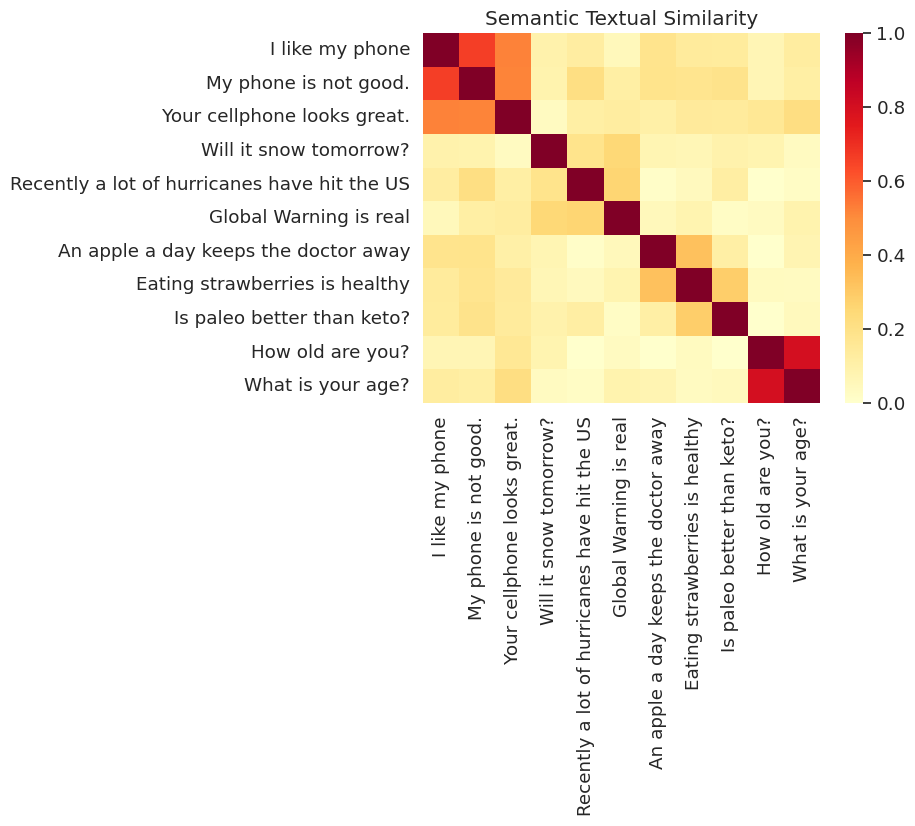

In [15]:
messages = [
    #Smartphones
    "I like my phone",
    "My phone is not good.",
    "Your cellphone looks great.",

    #Weather
    "Will it snow tomorrow?",
    "Recently a lot of hurricanes have hit the US",
    "Global Warning is real",

    #Food and health
    "An apple a day keeps the doctor away",
    "Eating strawberries is healthy",
    "Is paleo better than keto?",

    # Asking about age
    "How old are you?",
    "What is your age?"
]

run_and_plot(messages)